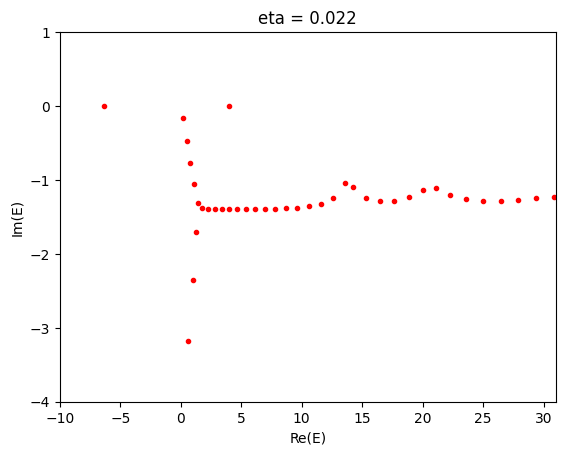

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 800 #size of basis
L = 16 #length of the box: computational domain. This is our stabilsation parameter
a = 1 # a geometrical parameter of the potential which specifies the position or width of the interaction region in the piecewise potential.
V = 10 # the strength (height or depth) of the potential
eta = 0.022

# Initialize Hamiltonian matrix
H = np.zeros((N, N), dtype=complex)

# Initialize vector
x = np.zeros((N, 1))
x[0] = 1

# Off-diagonal elements
for j in range(N-1):
    for k in range(j+1, N):

        jj = j + 1   # convert to MATLAB indexing
        kk = k + 1

        T1 = (2*V)/(np.pi*(jj+kk)) * np.sin(np.pi*a*(jj+kk)/L)
        T2 = -(2*V)/(np.pi*(kk-jj)) * np.sin(np.pi*a*(kk-jj)/L)
        T3 = (V/(np.pi*(kk-jj))) * np.sin(2*np.pi*a*(kk-jj)/L)
        T4 = -(V/(np.pi*(kk+jj))) * np.sin(2*np.pi*a*(kk+jj)/L)

        T5 = -1j*eta*((-1)**(kk-jj))*(2*L*(L-2*a))/(np.pi**2*(kk-jj)**2)
        T6 = 1j*eta*((-1)**(kk+jj))*(2*L*(L-2*a))/(np.pi**2*(kk+jj)**2)

        T7 = -1j*eta*(2*L**2/(np.pi**3*(kk-jj)**3))*np.sin(2*np.pi*(kk-jj)*a/L)
        T8 = 1j*eta*(2*L**2/(np.pi**3*(kk+jj)**3))*np.sin(2*np.pi*(kk+jj)*a/L)

        H[j, k] = T1 + T2 + T3 + T4 + T5 + T6 + T7 + T8
        H[k, j] = H[j, k]

# Diagonal elements
for j in range(N):

    jj = j + 1

    S1 = (np.pi**2 * jj**2)/(2*L**2)
    S2 = V/(np.pi*jj)*np.sin(2*np.pi*jj*a/L)
    S3 = -V/(2*np.pi*jj)*np.sin(4*np.pi*jj*a/L)

    S4 = -1j*eta*(L-2*a)**3/(3*L)
    S5 = 1j*eta*(L*(L-2*a)/(2*np.pi**2*jj**2))
    S6 = 1j*eta*(L**2)/(4*np.pi**2*jj**2)*np.sin(4*np.pi*jj*a/L)

    H[j, j] = S1 + S2 + S3 + S4 + S5 + S6

# Eigenvalues
E = np.linalg.eigvals(H)

# Special condition
if eta == 0:
    E = np.append(E, 10j)

# Plot eigenvalues
plt.plot(E.real, E.imag, '.r')
plt.xlim([-10, 31])
plt.ylim([-4, 1])

plt.xlabel("Re(E)")
plt.ylabel("Im(E)")
plt.title("eta = 0.022")

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

In [ ]:
#lambdas = np.linspace(0.5, 5.0, 200)
N = 800
L = 16
a = 1
V = 10

In [ ]:
def Hamiltonian(L):

    H = np.zeros((N, N))

    # off-diagonal
    for j in range(N-1):
        for k in range(j+1, N):

            jj = j + 1
            kk = k + 1

            T1 = (2*V)/(np.pi*(jj+kk)) \
                 * np.sin(np.pi*a*(jj+kk)/L)

            T2 = -(2*V)/(np.pi*(kk-jj)) \
                 * np.sin(np.pi*a*(kk-jj)/L)

            T3 = (V)/(np.pi*(kk-jj)) \
                 * np.sin(2*np.pi*a*(kk-jj)/L)

            T4 = -(V)/(np.pi*(kk+jj)) \
                 * np.sin(2*np.pi*a*(kk+jj)/L)

            H[j, k] = T1 + T2 + T3 + T4
            H[k, j] = H[j, k]

    # diagonal
    for j in range(N):

        jj = j + 1

        S1 = (np.pi**2 * jj**2)/(2*L**2)

        S2 = (V/(np.pi*jj)) \
             * np.sin(2*np.pi*jj*a/L)

        S3 = -(V/(2*np.pi*jj)) \
             * np.sin(4*np.pi*jj*a/L)

        H[j, j] = S1 + S2 + S3

    return H

In [ ]:
L_values = np.linspace(8, 30, 500)
#L_values = np.linspace(8, 30, 200)
#L_values = np.linspace(0.1, 0.5, 200) yielded nothing
#L_values = np.linspace(1, 5, 200)

In [ ]:
all_energies = []

for L in L_values:

    H = Hamiltonian(L)

    E, C = eigh(H)

    all_energies.append(E)

all_energies = np.array(all_energies)

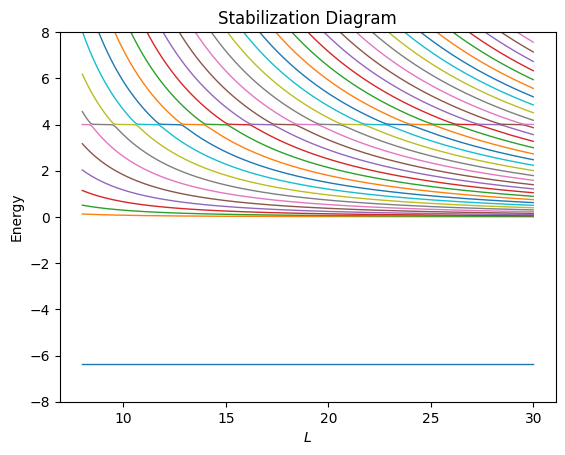

In [ ]:
n_states = 200

for n in range(n_states):
    plt.plot(
        L_values,
        all_energies[:, n],
        lw=1
    )
#plt.xlim([1, 2])
plt.ylim([-8, 8])
plt.xlabel(r'$L$')
plt.ylabel('Energy')
plt.title('Stabilization Diagram')
plt.show()

In [ ]:
#print(all_energies[:,9])
slopes = np.gradient(
    all_energies,
    L_values,
    axis=0
)

In [ ]:
tol = 1e-3

indices = np.where(
    np.abs(slopes) < tol
)

In [ ]:
slopes = np.gradient(
    all_energies[:, n],
    L_values
)

k = np.argmin(np.abs(slopes))

E_res = all_energies[k, n]
L_res = L_values[k]

print("Resonance energy =", E_res)
print("L =", L_res)
print("minimum slope =", slopes[k])

Resonance energy = 219.31080162774808
L = 30.0
minimum slope = -14.676312411786505


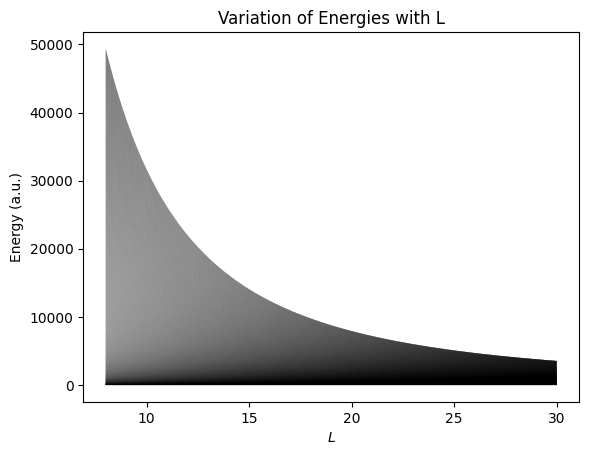

In [ ]:
roots = np.array(all_energies).T

for root in roots:
    plt.plot(L_values, root, 'k-', lw=0.09)

plt.title('Variation of Energies with L')
plt.xlabel(r'$L$')
plt.ylabel('Energy (a.u.)')
plt.show()

In [ ]:
def compute_DOS(gamma_values, all_energies):
    """
    Compute the density of states for all roots.
    """

    n_L, n_states = all_energies.shape

    DOS = np.zeros_like(all_energies)

    for n in range(n_states):

        E = all_energies[:, n]

        dEdL = np.gradient(E, L_values)

        eps = 1e-12
        DOS[:, n] = 1.0/(np.abs(dEdL) + eps)

    return DOS

In [ ]:
DOS = compute_DOS(L_values, all_energies)
DOS

array([[2.81115023e+06, 2.46942908e+01, 6.18093164e+00, ...,
        8.21388323e-05, 8.19332099e-05, 8.17279344e-05],
       [2.87014080e+06, 2.49547422e+01, 6.24604304e+00, ...,
        8.28129677e-05, 8.26057272e-05, 8.23994903e-05],
       [3.31822022e+06, 2.54848942e+01, 6.37857643e+00, ...,
        8.41821051e-05, 8.39715675e-05, 8.37620615e-05],
       ...,
       [2.41164322e+05, 2.25663909e+03, 5.64166832e+02, ...,
        4.25802946e-03, 4.24718965e-03, 4.23645026e-03],
       [3.24483056e+05, 2.26726412e+03, 5.66823091e+02, ...,
        4.27715591e-03, 4.26622473e-03, 4.25536822e-03],
       [3.90317364e+05, 2.27259750e+03, 5.68156436e+02, ...,
        4.28676280e-03, 4.27579529e-03, 4.26488628e-03]])

In [ ]:
def plot_stabilization(L_values,
                       all_energies,
                       n_roots=None):

    if n_roots is None:
        n_roots = all_energies.shape[1]

    plt.figure(figsize=(10,8))

    for n in range(n_roots):
        plt.plot(
            L_values,
            all_energies[:, n],
           lw=1
        )
    #for n in range(40, 81):
    #  plt.plot(L_values, all_energies[:,n], lw=1)

    plt.xlabel(r'$L$')
    plt.ylabel('Energy (a.u.)')
    plt.title('Stabilisation Diagram for L values between 1-5')
    #plt.grid(True)
    #plt.ylim([1000, 7000])
    #plt.xlim([1, 3])
    plt.savefig("stab_diagram.png")
    plt.show()

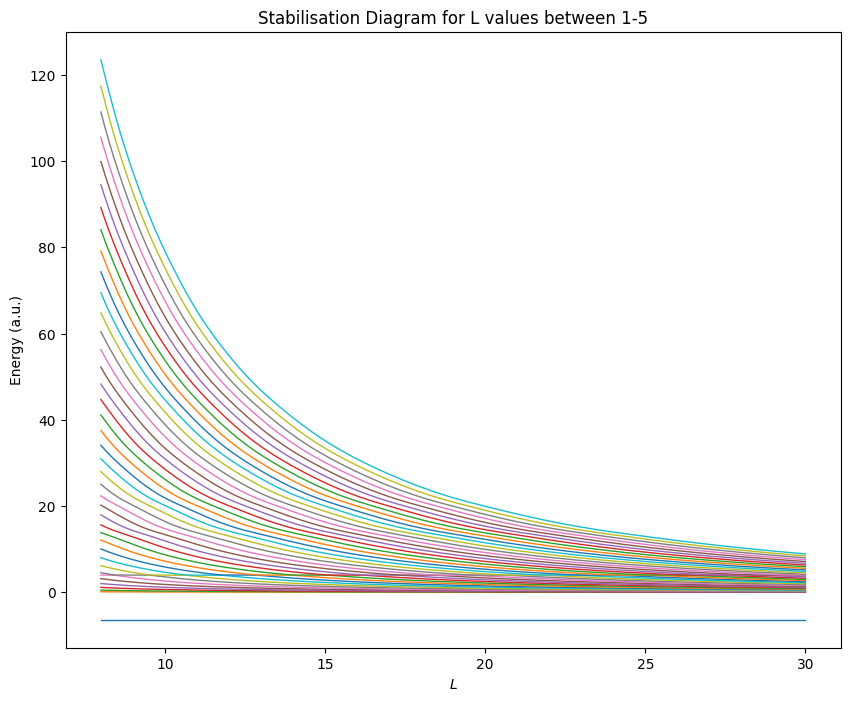

In [ ]:
plot_stabilization(
    L_values,
    all_energies,
    n_roots= 40
)

In [ ]:
all_energies.shape

(500, 800)

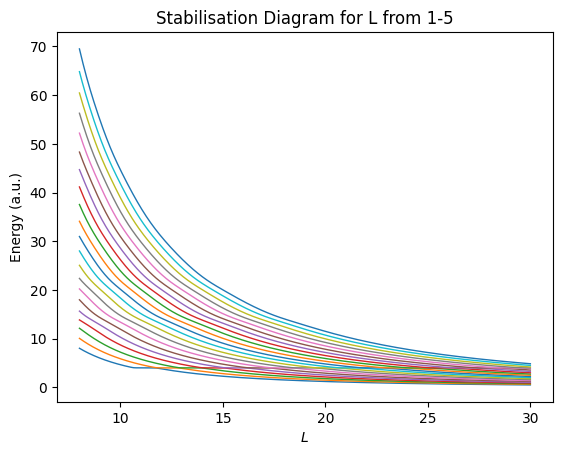

In [ ]:
start = 10
end = 30

for n in range(start-1, end):
    plt.plot(
        L_values,
        all_energies[:, n],
        lw=1
    )
    #plt.xlim([18, 30])
    #plt.ylim([0,8])
    plt.xlabel(r'$L$')
    plt.ylabel('Energy (a.u.)')
    plt.title('Stabilisation Diagram for L from 1-5')

In [ ]:
def plot_DOS(L_values,
             all_energies,
             DOS,
             root):

    E = all_energies[:, root]

    rho = DOS[:, root]

    plt.figure(figsize=(8,6))

    plt.plot(E, rho, 'o-')

    plt.xlabel('Energy (a.u.)')
    plt.ylabel('Density of States')
    plt.title(f'DOS of root {root}')
    #plt.grid(True)
    #plt.xlim([3.9,4.1])

    plt.show()

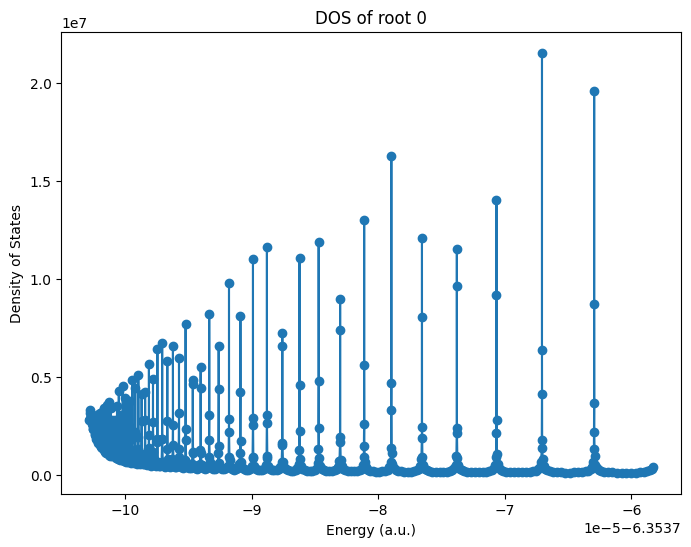

In [ ]:
plot_DOS(
    L_values,
    all_energies,
    DOS,
    root=0
)

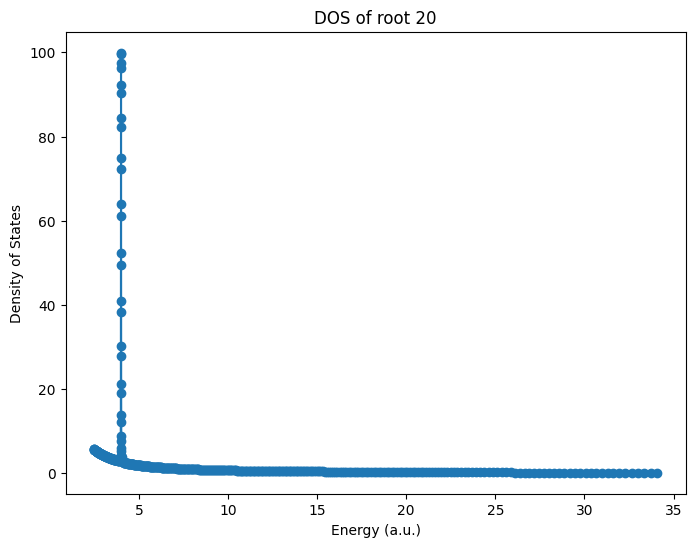

In [ ]:
plot_DOS(
    L_values,
    all_energies,
    DOS,
    root=20
)

In [ ]:
def find_resonance(
        L_values,
        all_energies,
        DOS,
        root):

    rho = DOS[:, root]

    E = all_energies[:, root]

    k = np.argmax(rho)

    E_res = E[k]

    L_res = L_values[k]

    rho_max = rho[k]

    return E_res, L_res, rho_max

In [ ]:
E_res, L_res, rho_max = find_resonance(
    L_values,
    all_energies,
    DOS,
    root=3
)

print("Resonance energy =", E_res)
print("L =", L_res)
print("DOS peak =", rho_max)

Resonance energy = 0.05575448273564909
L = 30.0
DOS peak = 252.5192192665832


In [ ]:
def find_all_resonances(
        L_values,
        all_energies,
        DOS):

    n_states = all_energies.shape[1]

    resonances = []

    for root in range(n_states):

        E_res, L_res, rho_max = find_resonance(
            L_values,
            all_energies,
            DOS,
            root
        )

        resonances.append({
            'root': root,
            'energy': E_res,
            'L': L_res,
            'dos_peak': rho_max
        })

    return resonances

In [ ]:
resonances = find_all_resonances(
    L_values,
    all_energies,
    DOS
)

#for r in resonances:
#    print(r)

In [ ]:
root_dict = {}

n_states = all_energies.shape[1]

for n in range(n_states):
    root_dict[n] = all_energies[:, n]

In [ ]:
#root_dict[3.0]

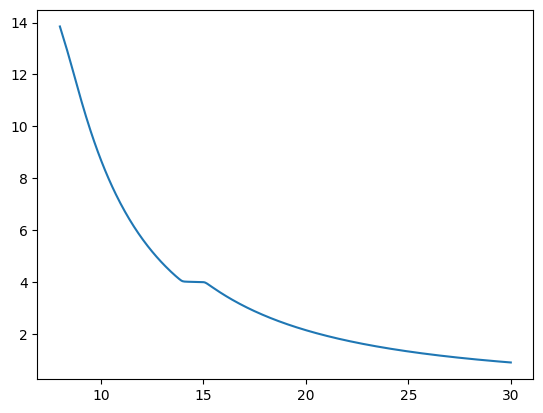

In [ ]:
#choosing a branch that appears stabilised
n = 12

plt.plot(
    L_values,
    all_energies[:,n]
)

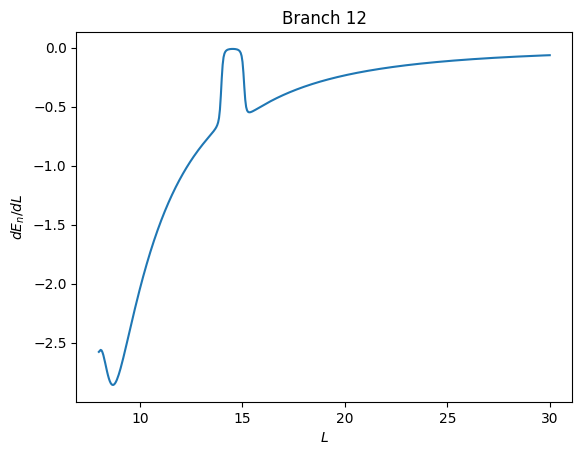

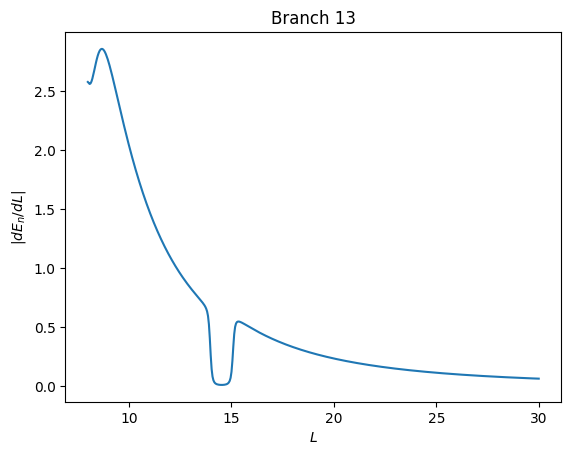

L_res = 14.525050100200401
E_res = 4.001479777121548


In [ ]:
E = all_energies[:,52]

dEdL = np.gradient(
    all_energies,
    L_values,
    axis=0
)
#dEdL
#n = 49   # Python indexing starts at 0

dEdL_n = np.gradient(
    all_energies[:, n],
    L_values
)
dEdL_n

dE = np.gradient(E, L_values)
d2E = np.gradient(dE, L_values)
#d2E
plt.plot(
    L_values,
    dEdL_n
)

plt.xlabel(r'$L$')
plt.ylabel(r'$dE_n/dL$')
plt.title(f'Branch {n}')
plt.show()

plt.plot(
    L_values,
    np.abs(dEdL_n)
)

plt.xlabel(r'$L$')
plt.ylabel(r'$|dE_n/dL|$')
plt.title(f'Branch {n+1}')
plt.show()

idx = np.argmin(np.abs(dEdL_n))

L_res = L_values[idx]
E_res = all_energies[idx, n]

print("L_res =", L_res)
print("E_res =", E_res)

In [ ]:
dEdL = np.gradient(
    all_energies,
    L_values,
    axis=0
)
#dEdL
n = 49   # Python indexing starts at 0

dEdL_n = np.gradient(
    all_energies[:, n],
    L_values
)
dEdL_n

array([-47.86048256, -47.46275419, -46.65830273, -45.84442713,
       -45.03941227, -44.26194994, -43.52756398, -42.84579579,
       -42.21868572, -41.640825  , -41.10085008, -40.58387782,
       -40.07419861, -39.55762094, -39.02311179, -38.4636623 ,
       -37.87650997, -37.2629242 , -36.62773158, -35.97867782,
       -35.32564591, -34.67971244, -34.05203917, -33.45266076,
       -32.88930969, -32.36648343, -31.88495173, -31.44182282,
       -31.03116068, -30.64500541, -30.27457347, -29.91139723,
       -29.54823223, -29.17964988, -28.80231135, -28.41498627,
       -28.0183816 , -27.61485096, -27.20802861, -26.80240666,
       -26.40287723, -26.01425403, -25.64080371, -25.28583201,
       -24.95137057, -24.638008  , -24.34489097, -24.06988798,
       -23.80988312, -23.56114641, -23.31971717, -23.08174926,
       -22.8437814 , -22.60291697, -22.35691729, -22.10422426,
       -21.84393366, -21.57573951, -21.29986777, -21.01700845,
       -20.72825351, -20.43504051, -20.13909839, -19.84

In [ ]:
curvature = np.gradient(
    slopes,
    L_values,
    axis=0
)

In [ ]:
idx = np.argmin(
    np.abs(slopes[:n])
)

Eres = all_energies[idx,n]
Lres = L_values[idx]

In [ ]:
def plot_DOS(data, root, file, fitted_peaks_by_root=None):
    """
    Plot the Density of States (DOS) for a specific root and save the plot.

    Parameters:
    data (dict): The parsed data containing energy and DOS arrays.
    root (int): The root identifier for the data to plot.
    fitted_peaks_by_root (dict, optional): Dictionary of fitted peaks by root. Defaults to None.
    """
    x_data = data["L"][1:-1]
    y_data = data[root][1:-1]
    plt.figure(figsize=(12, 8))
    plt.scatter(x_data, y_data, edgecolor='red', facecolor='none')
    if fitted_peaks_by_root is not None:
        for peak in fitted_peaks_by_root[root]:
            plt.plot([min(x_data), max(x_data)], [peak.energy(), peak.energy()], 'r-')
    plt.savefig(file)
    #plt.close('all')
    #open_file(file)
    from PIL import Image
    Image.open(file).show()

In [ ]:

from matplotlib.colors import Normalize, hsv_to_rgb
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter, AutoMinorLocator, MultipleLocator, FormatStrFormatter, MaxNLocator, \
    AutoLocator, LogLocator, NullFormatter, FixedLocator
from matplotlib.transforms import Affine2D


In [ ]:
def get_root_color(rootnr: int, alpha=1.):
    saturation = 1
    value = 0.7
    hue = (rootnr * 222.5+15) % 360
    hue /= 360.0
    rgb = hsv_to_rgb((hue, saturation, value))
    if alpha != 1:
        rgb = (1 - alpha) * np.array([1, 1, 1]) + alpha * rgb
    return rgb


In [ ]:
def plot_stabilization(L_values,
                       all_energies,
                       n_roots=None):

    if n_roots is None:
        n_roots = all_energies.shape[1]

    plt.figure(figsize=(10,8))

    for n in range(n_roots):
        plt.plot(
            L_values,
            all_energies[:, n],
            lw=1
        )

    plt.xlabel(r'$L$')
    plt.ylabel('Energy (a.u.)')
    plt.title('Stabilisation Diagram')
    #plt.grid(True)
    plt.show()

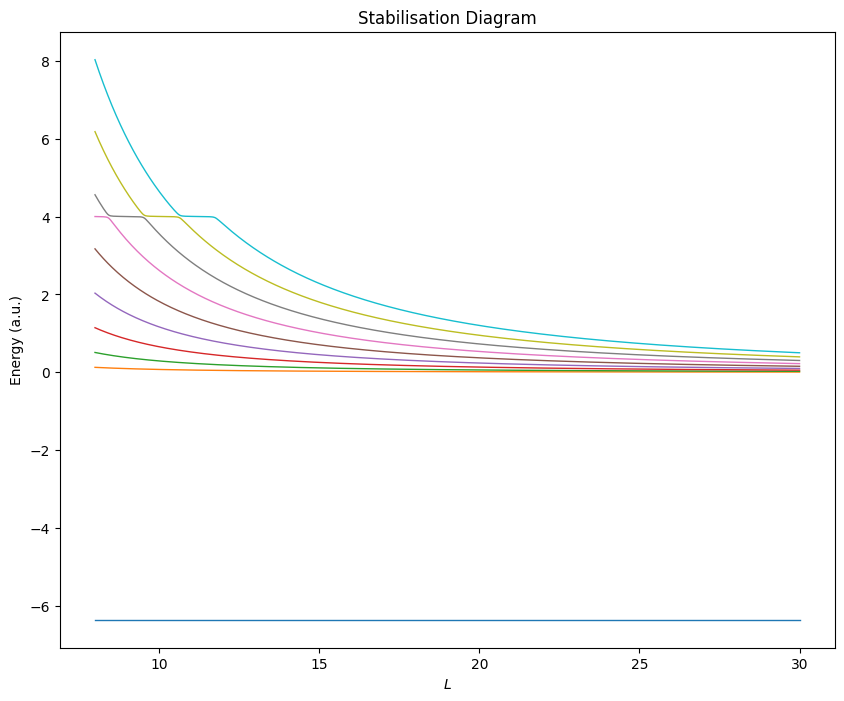

In [ ]:
plot_stabilization(
    L_values,
    all_energies,
    n_roots=10
)

In [ ]:
#data

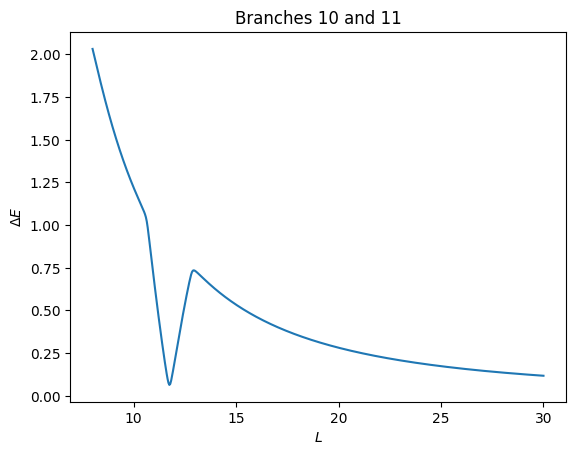

Minimum separation = 0.06391791414923276
L = 11.74749498997996


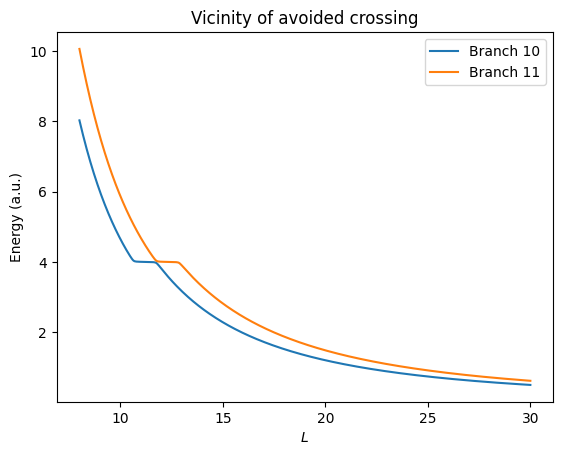

<Figure size 640x480 with 0 Axes>

In [ ]:
#compute the separation
n = 9   # branch 50

deltaE = np.abs(
    all_energies[:, n+1]
    - all_energies[:, n]
)

#plot the separation
plt.plot(L_values, deltaE)

plt.xlabel(r'$L$')
plt.ylabel(r'$\Delta E$')
plt.title(f'Branches {n+1} and {n+2}')
plt.show()

#find the minimum separation
idx = np.argmin(deltaE)

print("Minimum separation =", deltaE[idx])
print("L =", L_values[idx])

#zoom into the suspected region
plt.plot(
    L_values,
    all_energies[:, n],
    label=f'Branch {n+1}'
)

plt.plot(
    L_values,
    all_energies[:, n+1],
    label=f'Branch {n+2}'
)

plt.xlabel(r'$L$')
plt.ylabel('Energy (a.u.)')
plt.title('Vicinity of avoided crossing')
plt.legend()
plt.show()
plt.savefig('avoided_crossing.png')


#searching all neighbouring branches
threshold = 1e-3

for n in range(N-1):

    deltaE = np.abs(
        all_energies[:, n+1]
        - all_energies[:, n]
    )

    idx = np.argmin(deltaE)

    if deltaE[idx] < threshold:

        print(
            f"Possible avoided crossing between "
            f"branches {n+1} and {n+2}"
        )

        print(
            f"L = {L_values[idx]:.4f}, "
            f"gap = {deltaE[idx]:.6e}"
        )

In [ ]:
n = 10   # choose branch

E = all_energies[:, n]

dEdL = np.gradient(E, L_values)

DOS = 1.0/np.abs(dEdL)

#to avoid division by zero
eps = 1e-12
DOS = 1.0/(np.abs(dEdL) + eps)

#the Lorentzian
def lorentzian(E, A, Er, Gamma, C):

    return (
        A*(Gamma/2)**2
        /
        ((E-Er)**2 + (Gamma/2)**2)
        + C
    )

In [ ]:
from scipy.optimize import curve_fit

A0 = np.max(DOS)
Er0 = E[np.argmax(DOS)]
Gamma0 = 0.01
C0 = np.min(DOS)

p0 = [A0, Er0, Gamma0, C0]

#performing the fit
#popt, pcov = curve_fit(lorentzian,E,DOS,p0=p0)

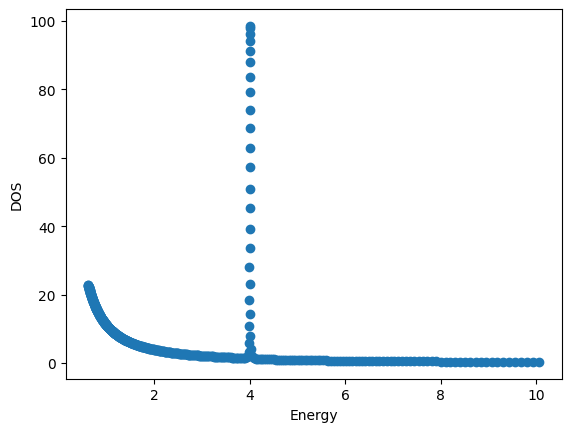

In [ ]:
# Plotting the data before fitting the plot
plt.plot(E, DOS, 'o')
plt.xlabel('Energy')
plt.ylabel('DOS')
plt.show()

# There's no clear peak, so the fit will fail if we try

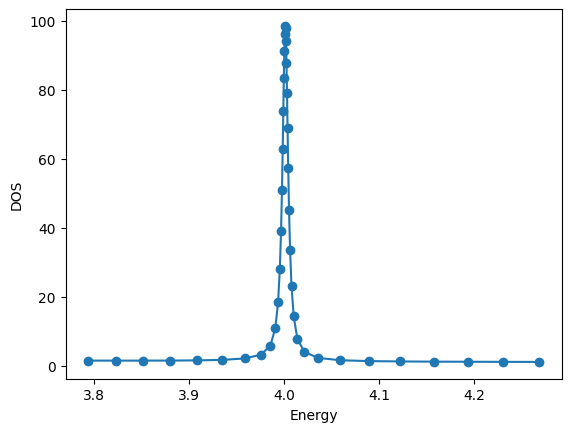

In [ ]:
# We thus remove infinities and NaNs
mask = np.isfinite(DOS)

E_fit = E[mask]
DOS_fit = DOS[mask]

#Instead of fitting the entire branch, we now fit only near the maximum
imax = np.argmax(DOS_fit)

window = 20

i1 = max(0, imax-window)
i2 = min(len(E_fit), imax+window)

E_peak = E_fit[i1:i2]
DOS_peak = DOS_fit[i1:i2]

#Then we plot
plt.plot(E_peak, DOS_peak, 'o-')
plt.xlabel('Energy')
plt.ylabel('DOS')
plt.show()

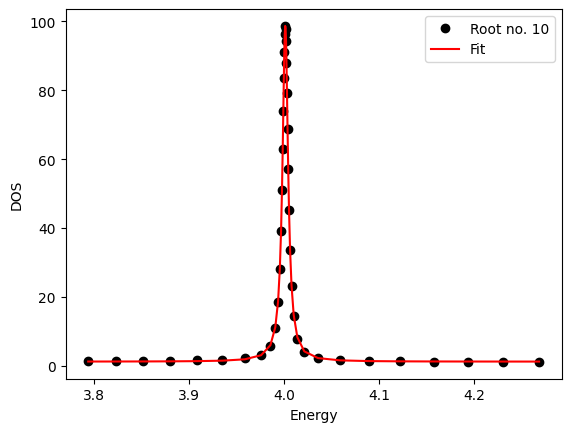

In [ ]:
#n=49
#We now improve our initial guesses
A0 = DOS_peak.max() - DOS_peak.min()
Er0 = E_peak[np.argmax(DOS_peak)]
Gamma0 = (E_peak.max() - E_peak.min())/10
C0 = DOS_peak.min()

p0 = [A0, Er0, Gamma0, C0]

#Put bounds on the parameters
lower = [0,
         E_peak.min(),
         1e-8,
         0]

upper = [np.inf,
         E_peak.max(),
         E_peak.max()-E_peak.min(),
         np.inf]
#Then, we increase maxfev to 1000 (which often fixes the problem)
popt, pcov = curve_fit(
    lorentzian,
    E_peak,
    DOS_peak,
    p0=p0,
    bounds=(lower, upper),
    maxfev=10000
)


#We plot the fit now
plt.plot(E_peak, DOS_peak, 'ko', label='Root no. 10')
plt.plot(E_peak, lorentzian(E_peak, *popt), 'r-', label='Fit')
plt.xlabel('Energy')
plt.ylabel('DOS')

plt.legend()
plt.show()

In [ ]:
Er0

np.float64(4.001305227980457)

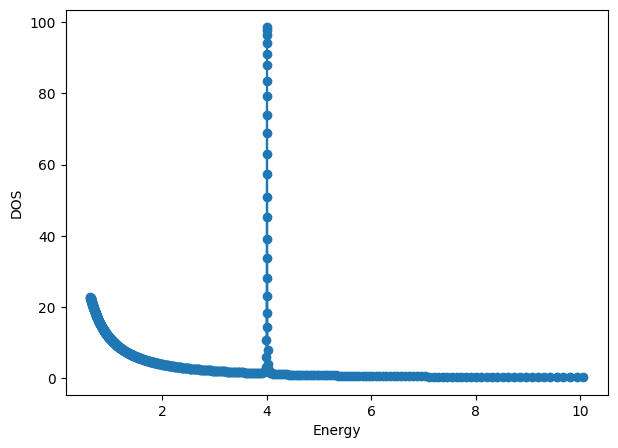

In [ ]:
n = 49

plt.figure(figsize=(7,5))
plt.plot(E, DOS, 'o-')
plt.xlabel('Energy')
plt.ylabel('DOS')
plt.show()

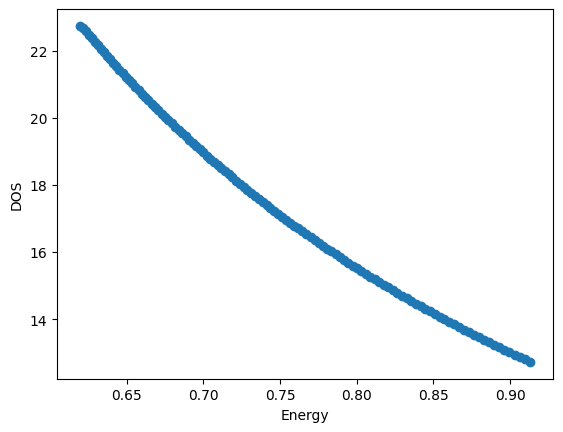

In [ ]:
mask = (L_values > 25.0)

E_peak = E[mask]
DOS_peak = DOS[mask]

plt.plot(E_peak, DOS_peak, 'o-')
plt.xlabel('Energy')
plt.ylabel('DOS')
plt.show()

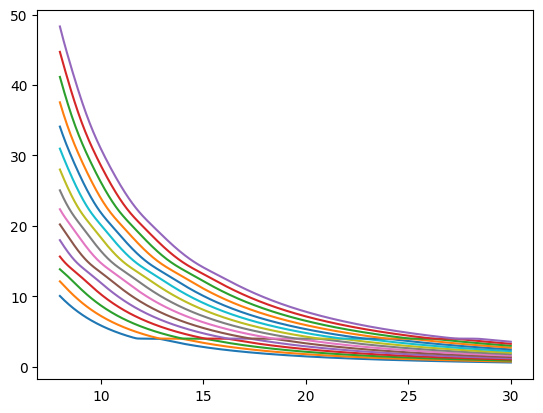

In [ ]:
for n in range(10,25):
    plt.plot(
        L_values,
        all_energies[:,n]
    )

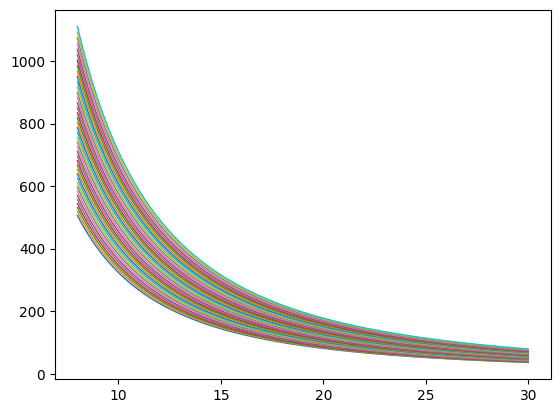

In [ ]:
for n in range(80,120):
    plt.plot(
        L_values,
        all_energies[:,n],
        lw=1
    )

In [ ]:
import pandas as pd

# Number of eigenvalues
N = all_energies.shape[1]

# Column names
first_cols = [f"E{i+1}" for i in range(10)]
last_cols = [f"E{N-9+i}" for i in range(10)]

# Create DataFrame
table = pd.DataFrame({
    "L": L_values
})

# Add first 10 eigenvalues
for i in range(10):
    table[first_cols[i]] = all_energies[:, i]

# Add last 10 eigenvalues
for i in range(10):
    table[last_cols[i]] = all_energies[:, N-10+i]

# Display the table
print(table)

             L        E1        E2        E3        E4        E5        E6  \
0     8.000000 -6.353803  0.127384  0.509292  1.144950  2.032860  3.169943   
1     8.044088 -6.353803  0.125598  0.502159  1.128935  2.004487  3.125907   
2     8.088176 -6.353803  0.123850  0.495175  1.113253  1.976702  3.082768   
3     8.132265 -6.353803  0.122138  0.488335  1.097896  1.949489  3.040504   
4     8.176353 -6.353803  0.120462  0.481636  1.082853  1.922831  2.999092   
..         ...       ...       ...       ...       ...       ...       ...   
495  29.823647 -6.353759  0.006273  0.025093  0.056458  0.100368  0.156823   
496  29.867735 -6.353759  0.006253  0.025014  0.056281  0.100053  0.156331   
497  29.911824 -6.353759  0.006234  0.024936  0.056104  0.099740  0.155842   
498  29.955912 -6.353758  0.006214  0.024858  0.055929  0.099428  0.155354   
499  30.000000 -6.353758  0.006195  0.024780  0.055754  0.099118  0.154869   

           E7        E8        E9  ...          E791          E

In [ ]:
table.to_csv("eigenvalues_vs_L.csv", index=False)

In [ ]:
# Read the CSV file
df = pd.read_csv("eigenvalues_vs_L.csv")

# Convert to LaTeX
latex_table = df.to_latex(
    index=False,
    float_format="%.6f"
)

# Save the LaTeX table
with open("eigenvalues_vs_L.tex", "w") as f:
    f.write(latex_table)

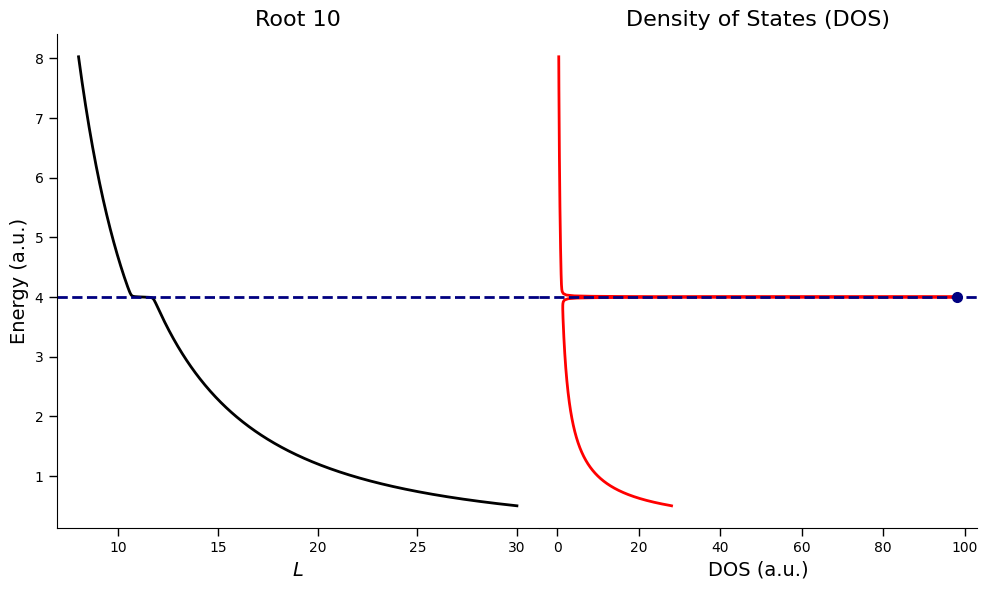

<Figure size 640x480 with 0 Axes>

In [ ]:

# Root number (Python indexing)
# -----------------------------
root = 9      # Root 10

E = all_energies[:, root]

# -----------------------------
# Density of states
# -----------------------------
dEdL = np.gradient(E, L_values)

eps = 1e-12
DOS = 1.0/(np.abs(dEdL)+eps)

# Sort for DOS plot
idx = np.argsort(E)
E_sorted = E[idx]
DOS_sorted = DOS[idx]

# Peak DOS
peak_idx = np.argmax(DOS_sorted)

E_peak = E_sorted[peak_idx]
DOS_peak = DOS_sorted[peak_idx]

# -----------------------------
# Figure
# -----------------------------
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(10,6),
    sharey=True,
    gridspec_kw={
        'width_ratios':[2.2,2],
        'wspace':0      # No space between panels
    }
)

# -----------------------------
# Left panel
# -----------------------------
ax1.plot(
    L_values,
    E,
    color='black',
    lw=2
)

ax1.set_xlabel(r"$L$", fontsize=14)
ax1.set_ylabel("Energy (a.u.)", fontsize=14)
ax1.set_title("Root 10", fontsize=16)

# -----------------------------
# Right panel
# -----------------------------
ax2.plot(
    DOS_sorted,
    E_sorted,
    color='red',
    lw=2
)

ax2.set_xlabel("DOS (a.u.)", fontsize=14)
ax2.set_title("Density of States (DOS)", fontsize=16)

# -----------------------------
# Continuous horizontal line
# -----------------------------
ax1.axhline(
    E_peak,
    color='navy',
    ls='--',
    lw=2
)

ax2.axhline(
    E_peak,
    color='navy',
    ls='--',
    lw=2
)

# Mark DOS peak
ax2.plot(
    DOS_peak,
    E_peak,
    'o',
    color='navy',
    ms=7
)

# -----------------------------
# Remove unwanted borders
# -----------------------------

# Left panel
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right panel
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

# Remove duplicate y-axis ticks on right panel
ax2.tick_params(axis='y', left=False, labelleft=False)

# No grids
ax1.grid(False)
ax2.grid(False)

# Improve tick appearance
ax1.tick_params(direction='out', length=6, width=1)
ax2.tick_params(direction='out', length=6, width=1)

plt.tight_layout()
plt.show()
plt.savefig("Combined_plot.png", dpi=300)